# DETECTING ANNOYANCES IN FINANCIAL DATA

## 1. Import data & Discover data

### 1.1 Import

In [369]:
import pandas as pd

df = pd.read_excel("~/Documentation/Data_finance.xlsx")

df.head()

,APP_ID,DISBURSALDATE,REPORT_DATE,TERM_TMP,PRODUCT_NAME,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,LA,EFF_RATE,TERM,...,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,MARITAL_STATUS,EDUCATION,City,ADDRESS_CURRENT_CITY,PROVINCE_CURRENT
0,16499318,2017-10-10,2018-10-26,12,FC UP DSA TS SCORE 2 NEW- 762,18000000,990000,18990000,45.0,24,...,9000000,0,9600000,20000000,5000000,Other,High School,Tỉnh Yên Bái,Yên Bình,Tỉnh Yên Bái
1,16490594,2017-10-10,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,10000000,550000,10550000,44.5,12,...,5500000,0,7200000,15000000,4000000,Married,High School,Tỉnh Quảng Ninh,Đông Triều,Tỉnh Quảng Ninh
2,16910227,2017-10-28,2018-10-26,11,FC UP CAT B NEW- 610,25000000,1375000,26375000,47.0,24,...,5182000,0,12000000,5200000,1000000,Single,Middle School,Tỉnh Bình Dương,Tân Uyên,Tỉnh Bình Dương
3,16355347,2017-10-04,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,30000000,1650000,31650000,44.5,24,...,10000000,0,18000000,20000000,6000000,Married,Middle School,Tỉnh An Giang,Phú Tân,Tỉnh An Giang
4,16705974,2017-10-18,2018-10-26,12,FC UP L.G 2 TSA SCORE NEW- 617,20000000,1100000,21100000,44.5,18,...,7000000,0,12000000,20000000,7000000,Single,High School,Thành phố Hải Phòng,Vĩnh Bảo,Thành phố Hải Phòng


### 1.2 Discovery

In [370]:
df.dtypes

APP_ID                               int64
DISBURSALDATE               datetime64[us]
REPORT_DATE                 datetime64[us]
TERM_TMP                             int64
PRODUCT_NAME                           str
LOANAMOUNT_NOT_INSURANCE             int64
INSURANCE_FEE                        int64
LA                                   int64
EFF_RATE                           float64
TERM                                 int64
COUNT_TERM_RECEIPT                 float64
flag term                          float64
SUM_RECEIPT_AMT                    float64
Unnamed: 13                        float64
flag loan amt                      float64
flag final                         float64
RESULT_YES/NO                        int64
EMI                                  int64
GENDER                                 str
AGE                                  int64
Number_of_Children                 float64
PERSONAL_INCOME                      int64
ADDITIONAL_INCOME                    int64
PERSONAL_EX

In [371]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   APP_ID                    5000 non-null   int64         
 1   DISBURSALDATE             5000 non-null   datetime64[us]
 2   REPORT_DATE               5000 non-null   datetime64[us]
 3   TERM_TMP                  5000 non-null   int64         
 4   PRODUCT_NAME              5000 non-null   str           
 5   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64         
 6   INSURANCE_FEE             5000 non-null   int64         
 7   LA                        5000 non-null   int64         
 8   EFF_RATE                  5000 non-null   float64       
 9   TERM                      5000 non-null   int64         
 10  COUNT_TERM_RECEIPT        4909 non-null   float64       
 11  flag term                 4909 non-null   float64       
 12  SUM_RECEIPT_AMT           4909 

In [372]:
df.isnull().sum()

APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT            91
flag term                     91
SUM_RECEIPT_AMT               91
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number_of_Children          4200
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [373]:
df["Unnamed: 13"].nunique()

143

In [374]:
df["Unnamed: 13"].head()

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: Unnamed: 13, dtype: float64

In [375]:
df["Unnamed: 13"].unique()

array([           nan, 8.64413715e-03, 2.49787455e-01, 4.17829850e-03,
       9.80138701e-02, 6.83073402e-02, 6.15512868e-05, 4.72423490e-04,
       7.66163311e-02, 3.33919176e-03, 3.45466500e-03, 1.81426020e-02,
       6.01744655e-04, 1.56612960e-02, 1.59845384e-01, 0.00000000e+00,
       4.53460621e-02, 1.57121407e-01, 7.80770362e-02, 2.62962748e-03,
       1.52372818e-03, 1.28369776e-03, 1.55926963e-02, 2.27208794e-03,
       3.97806674e-02, 2.43269204e-01, 5.60068362e-02, 4.63046539e-03,
       7.83468333e-02, 1.23418363e-03, 5.75638006e-04, 7.26011241e-03,
       8.06304771e-02, 4.72636816e-02, 1.36539824e-02, 1.68188768e-02,
       3.25623632e-02, 7.31192904e-03, 1.85690690e-04, 2.17208905e-03,
       4.90630320e-03, 1.61328148e-01, 2.09979766e-04, 3.35875946e-03,
       7.51762140e-02, 7.34206141e-02, 7.66777438e-02, 8.40243428e-03,
       7.28809854e-05, 1.02048418e-02, 1.31805262e-01, 7.73606088e-02,
       7.59885525e-02, 1.65944263e-03, 1.71505029e-03, 8.56662660e-03,
      

**Attention:**
The columns `Unnamed: 13` has only 151 values, remaining data of this column is NaN. And when I open .xlsx file. I do not see this column. Maybe it is a hidden column, and it does not support to traning process. So I have to drop this column.

**`Requried:`**
I have to calculate the extra col:
`"INCOME" = ("PERSONAL_INCOME" + "ADDITIONAL_INCOME" + "FAMILY_INCOME") - ("PERSONAL_EXPENSE" + "FAMILY_EXPENSE")`

In [376]:
df["INCOME"] = df["PERSONAL_INCOME"] + df["ADDITIONAL_INCOME"] + df["FAMILY_INCOME"] - df["PERSONAL_EXPENSE"] + df["FAMILY_EXPENSE"]
df["INCOME"]

0       24400000
1       17300000
2        -618000
3       18000000
4       22000000
          ...   
4995    41000000
4996    27000000
4997    28500000
4998    24000000
4999    20000000
Name: INCOME, Length: 5000, dtype: int64

### 1.3 Check missing values

In [377]:
df.isnull().sum()

APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT            91
flag term                     91
SUM_RECEIPT_AMT               91
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number_of_Children          4200
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

In [378]:
df["Number_of_Children"].unique()

array([nan,  2.,  0.,  1.,  3.,  4.,  8.,  6.,  5.,  7.])

In [379]:
df["Number_of_Children"] = df["Number_of_Children"].fillna(0)

As I known that if `COUNT_TERM_RECEIPT` and `SUM_RECEIPT_AMT` is NaN. It means I get debtor, so I have to create a columns stand for that.
**NPL: Non-Performing Loan**: columns represent for bad debt
After that I can fill the blank (na) at `COUNT_TERM_RECEIPT` or `SUM_RECEIPT_AMT`

In [380]:
df["NPL"] = (df["COUNT_TERM_RECEIPT"].isnull() & df["SUM_RECEIPT_AMT"].isnull()).astype(int)
df["NPL"].unique()

array([0, 1])

In [381]:
(df["NPL"] == 1).sum(),(df["NPL"] == 0).sum()

(np.int64(91), np.int64(4909))

In [382]:
df["COUNT_TERM_RECEIPT"] = df["COUNT_TERM_RECEIPT"].fillna(0)
df["SUM_RECEIPT_AMT"] = df["SUM_RECEIPT_AMT"].fillna(0)


In [383]:
df.isnull().sum()

APP_ID                         0
DISBURSALDATE                  0
REPORT_DATE                    0
TERM_TMP                       0
PRODUCT_NAME                   0
LOANAMOUNT_NOT_INSURANCE       0
INSURANCE_FEE                  0
LA                             0
EFF_RATE                       0
TERM                           0
COUNT_TERM_RECEIPT             0
flag term                     91
SUM_RECEIPT_AMT                0
Unnamed: 13                 4849
flag loan amt                 91
flag final                    91
RESULT_YES/NO                  0
EMI                            0
GENDER                         0
AGE                            0
Number_of_Children             0
PERSONAL_INCOME                0
ADDITIONAL_INCOME              0
PERSONAL_EXPENSE               0
FAMILY_INCOME                  0
FAMILY_EXPENSE                 0
MARITAL_STATUS                 0
EDUCATION                      0
City                           0
ADDRESS_CURRENT_CITY           0
PROVINCE_C

Oops, I see `ADDRESS_CURRENT_CITY` contain 639 unique values.
I think that I should drop this column. If I use label encode for 639, the feature will expand more column.

In [384]:
df["City"].nunique(),df["PROVINCE_CURRENT"].nunique(), df["ADDRESS_CURRENT_CITY"].nunique()

(67, 67, 639)

In [385]:
(df["City"] == df["PROVINCE_CURRENT"]).sum()

np.int64(5000)

In [386]:
AGE_DAYS = (df["REPORT_DATE"] - df["DISBURSALDATE"]).dt.days / 30
AGE_DAYS

0       12.700000
1       12.700000
2       12.100000
3       12.900000
4       12.433333
          ...    
4995    12.233333
4996    12.633333
4997    12.033333
4998    12.933333
4999    12.466667
Length: 5000, dtype: float64

In [387]:
df["TERM_TMP"]

0       12
1       12
2       11
3       12
4       12
        ..
4995    12
4996    12
4997    12
4998    12
4999    12
Name: TERM_TMP, Length: 5000, dtype: int64

In [388]:
df = df.drop(columns=["ADDRESS_CURRENT_CITY", "PROVINCE_CURRENT"])

In [389]:
valid = df.dropna(subset=["flag term", "flag loan amt", "flag final"])

test = ((valid["flag term"] == 1)& (valid["flag loan amt"] == 1)).astype(int)

(test== valid["flag final"]).value_counts()

True    4909
Name: count, dtype: int64

In [390]:
df.dtypes

APP_ID                               int64
DISBURSALDATE               datetime64[us]
REPORT_DATE                 datetime64[us]
TERM_TMP                             int64
PRODUCT_NAME                           str
LOANAMOUNT_NOT_INSURANCE             int64
INSURANCE_FEE                        int64
LA                                   int64
EFF_RATE                           float64
TERM                                 int64
COUNT_TERM_RECEIPT                 float64
flag term                          float64
SUM_RECEIPT_AMT                    float64
Unnamed: 13                        float64
flag loan amt                      float64
flag final                         float64
RESULT_YES/NO                        int64
EMI                                  int64
GENDER                                 str
AGE                                  int64
Number_of_Children                 float64
PERSONAL_INCOME                      int64
ADDITIONAL_INCOME                    int64
PERSONAL_EX

In [391]:
df["RESULT_YES/NO"].value_counts()

RESULT_YES/NO
1    3636
0    1364
Name: count, dtype: int64

In [392]:
(df["LA"]==df["LOANAMOUNT_NOT_INSURANCE"]+ df["INSURANCE_FEE"]).mean()

np.float64(1.0)

In [393]:
df = df.drop(
    columns=[
        "APP_ID",
        "Unnamed: 13",
        "flag term",
        "flag loan amt",
        "flag final",
        "LA",
		"DISBURSALDATE",
        "REPORT_DATE"
    ])
df.columns

Index(['TERM_TMP', 'PRODUCT_NAME', 'LOANAMOUNT_NOT_INSURANCE', 'INSURANCE_FEE',
       'EFF_RATE', 'TERM', 'COUNT_TERM_RECEIPT', 'SUM_RECEIPT_AMT',
       'RESULT_YES/NO', 'EMI', 'GENDER', 'AGE', 'Number_of_Children',
       'PERSONAL_INCOME', 'ADDITIONAL_INCOME', 'PERSONAL_EXPENSE',
       'FAMILY_INCOME', 'FAMILY_EXPENSE', 'MARITAL_STATUS', 'EDUCATION',
       'City', 'INCOME', 'NPL'],
      dtype='str')

In [394]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

print(categorical_cols)

['PRODUCT_NAME', 'GENDER', 'MARITAL_STATUS', 'EDUCATION', 'City']


In [395]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TERM_TMP                  5000 non-null   int64  
 1   PRODUCT_NAME              5000 non-null   str    
 2   LOANAMOUNT_NOT_INSURANCE  5000 non-null   int64  
 3   INSURANCE_FEE             5000 non-null   int64  
 4   EFF_RATE                  5000 non-null   float64
 5   TERM                      5000 non-null   int64  
 6   COUNT_TERM_RECEIPT        5000 non-null   float64
 7   SUM_RECEIPT_AMT           5000 non-null   float64
 8   RESULT_YES/NO             5000 non-null   int64  
 9   EMI                       5000 non-null   int64  
 10  GENDER                    5000 non-null   str    
 11  AGE                       5000 non-null   int64  
 12  Number_of_Children        5000 non-null   float64
 13  PERSONAL_INCOME           5000 non-null   int64  
 14  ADDITIONAL_INCOME  

In [396]:
df.describe()

,TERM_TMP,LOANAMOUNT_NOT_INSURANCE,INSURANCE_FEE,EFF_RATE,TERM,COUNT_TERM_RECEIPT,SUM_RECEIPT_AMT,RESULT_YES/NO,EMI,AGE,Number_of_Children,PERSONAL_INCOME,ADDITIONAL_INCOME,PERSONAL_EXPENSE,FAMILY_INCOME,FAMILY_EXPENSE,INCOME,NPL
count,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5.000000e+03,5000.000000
mean,12.003200,1.564802e+07,7.934629e+05,36.797372,15.046800,8.310000,1.314685e+07,0.727200,1.373196e+06,34.283000,0.281600,8.563299e+06,7.600000e+03,8.464034e+06,2.180893e+07,4.473954e+06,2.638975e+07,0.018200
std,0.059921,1.196323e+07,6.654844e+05,21.158261,8.907776,3.525051,9.905402e+06,0.445443,6.898423e+05,9.898874,0.746735,4.176414e+06,1.638524e+05,9.692969e+06,1.124716e+07,2.307437e+06,1.440133e+07,0.133687
min,11.000000,1.200000e+06,0.000000e+00,0.000000,3.000000,0.000000,0.000000e+00,0.000000,2.660000e+05,18.000000,0.000000,2.200000e+06,0.000000e+00,2.000000e+05,2.000000e+06,5.000000e+05,-5.700000e+07,0.000000
25%,12.000000,4.940000e+06,2.536380e+05,33.500000,6.000000,6.000000,5.288090e+06,0.000000,8.435000e+05,26.000000,0.000000,6.000000e+06,0.000000e+00,1.000000e+06,1.500000e+07,3.000000e+06,1.860000e+07,0.000000
50%,12.000000,1.200000e+07,5.500000e+05,44.500000,12.000000,9.000000,1.062600e+07,1.000000,1.278378e+06,33.000000,0.000000,8.000000e+06,0.000000e+00,4.900000e+06,2.000000e+07,4.000000e+06,2.560000e+07,0.000000
75%,12.000000,2.500000e+07,1.100000e+06,47.000000,24.000000,12.000000,1.915275e+07,1.000000,1.785462e+06,41.000000,0.000000,1.000000e+07,0.000000e+00,1.200000e+07,2.500000e+07,5.000000e+06,3.290000e+07,0.000000
max,13.000000,7.000000e+07,3.850000e+06,85.000000,36.000000,24.000000,8.252572e+07,1.000000,5.632000e+06,99.000000,8.000000,1.000000e+08,5.000000e+06,1.200000e+08,3.580000e+08,3.200000e+07,3.629720e+08,1.000000


In [397]:
y_true = df["RESULT_YES/NO"].copy()

X = df.drop(columns=["RESULT_YES/NO"]).copy()

In [398]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric columns:")
print(num_cols)

print("\nCategorical columns:")
print(cat_cols)

Numeric columns:
['TERM_TMP', 'LOANAMOUNT_NOT_INSURANCE', 'INSURANCE_FEE', 'EFF_RATE', 'TERM', 'COUNT_TERM_RECEIPT', 'SUM_RECEIPT_AMT', 'EMI', 'AGE', 'Number_of_Children', 'PERSONAL_INCOME', 'ADDITIONAL_INCOME', 'PERSONAL_EXPENSE', 'FAMILY_INCOME', 'FAMILY_EXPENSE', 'INCOME', 'NPL']

Categorical columns:
['PRODUCT_NAME', 'GENDER', 'MARITAL_STATUS', 'EDUCATION', 'City']


In [399]:
print(X[cat_cols].nunique().sort_values(ascending=False))

PRODUCT_NAME      174
City               67
EDUCATION           8
MARITAL_STATUS      5
GENDER              2
dtype: int64


# 2. Training model

In [400]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
	X, y_true, test_size=0.2, random_state=42, stratify=y_true
)



In [401]:
preprocessor = ColumnTransformer(
	transformers=[
		("num", StandardScaler(), num_cols),
		("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
	]
)

In [402]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
X_train_processed.shape,X_test_processed.shape

((4000, 265), (1000, 265))

In [403]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(4000, 265)
(1000, 265)


In [404]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch import nn
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
print(X_train_tensor.shape)
print(X_test_tensor.shape)

torch.Size([4000, 265])
torch.Size([1000, 265])


In [405]:
train_dataset = TensorDataset(X_train_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)



In [406]:
train_labels_batch, = next(iter(train_dataloader))
train_labels_batch.shape

torch.Size([32, 265])

In [407]:
input_dim = X_train_tensor.shape[1]
input_dim

265

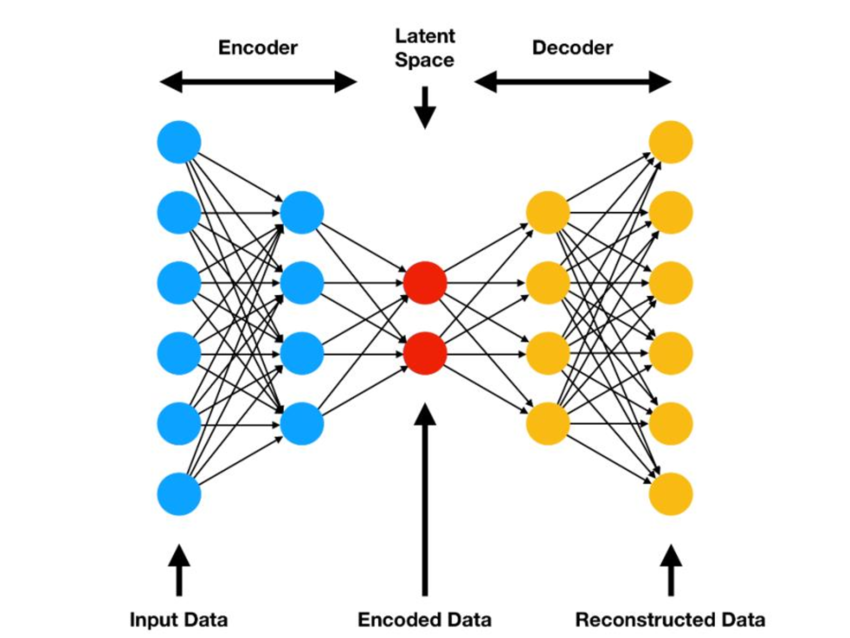

In [408]:
class AE(nn.Module):
	def __init__(self,input_dim):
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(input_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, 32),
			nn.ReLU(),
		)
		self.decoder = nn.Sequential(
			nn.Linear(32, 64),
			nn.ReLU(),
			nn.Linear(64, 128),
			nn.ReLU(),
			nn.Linear(128, input_dim),
		)

	def forward(self, x):
		encoded = self.encoder(x)
		decoded = self.decoder(encoded)
		return decoded

In [409]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [410]:

model = AE(input_dim=input_dim).to(device)
model

AE(
  (encoder): Sequential(
    (0): Linear(in_features=265, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=265, bias=True)
  )
)

In [411]:
loss_fn = nn.MSELoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

def train_step(model, dataloader, loss_fn, optimizer, epochs, device,noise_factor = None,):
	model.train()
	history = []

	for epoch in range(epochs):
		epoch_loss = 0.0
		for batch in dataloader:
			X_batch = batch[0].to(device)
			if noise_factor is not None:
				noisy_X = (X_batch + noise_factor * torch.randn_like(X_batch))
				reconstructed = model(noisy_X)
			else:
				
				reconstructed = model(X_batch)
			
			loss = loss_fn(reconstructed, X_batch)
			optimizer.zero_grad()
			loss.backward()
			optimizer.step()

			epoch_loss += loss.item()

		avg_epoch_loss = epoch_loss / len(dataloader)
		history.append(avg_epoch_loss)
		print(f"Epoch [{epoch + 1}/{epochs}], Loss: {avg_epoch_loss:.4f}")

	return history


In [412]:
EPOCHS = 20

history = train_step(model, train_dataloader, loss_fn, optimizer, EPOCHS, device)


Epoch [1/20], Loss: 0.0602
Epoch [2/20], Loss: 0.0382
Epoch [3/20], Loss: 0.0282
Epoch [4/20], Loss: 0.0231
Epoch [5/20], Loss: 0.0190
Epoch [6/20], Loss: 0.0171
Epoch [7/20], Loss: 0.0151
Epoch [8/20], Loss: 0.0145
Epoch [9/20], Loss: 0.0136
Epoch [10/20], Loss: 0.0122
Epoch [11/20], Loss: 0.0116
Epoch [12/20], Loss: 0.0111
Epoch [13/20], Loss: 0.0106
Epoch [14/20], Loss: 0.0103
Epoch [15/20], Loss: 0.0099
Epoch [16/20], Loss: 0.0097
Epoch [17/20], Loss: 0.0092
Epoch [18/20], Loss: 0.0089
Epoch [19/20], Loss: 0.0086
Epoch [20/20], Loss: 0.0084


In [413]:
import matplotlib.pyplot as plt


def plot_loss(history):

    plt.figure(figsize=(8, 5))

    plt.plot(history, marker="o")

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title("Training Loss")

    plt.grid(True)

    plt.show()

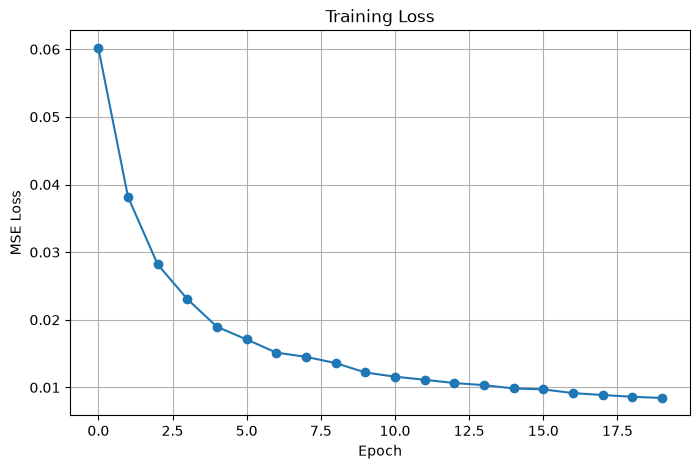

In [414]:
plot_loss(history)

In [415]:
model.eval()

with torch.inference_mode():

    X_test_device = X_test_tensor.to(device)

    reconstructed = model(X_test_device)

    reconstruction_errors = torch.mean((X_test_device - reconstructed) ** 2,dim=1).cpu().numpy()

In [416]:
model.eval()

with torch.inference_mode():

    X_train_device = X_train_tensor.to(device)

    train_reconstructed = model(X_train_device)

    train_errors = torch.mean((X_train_device - train_reconstructed) ** 2,dim=1).cpu().numpy()

In [417]:
print(train_errors.shape)
print(train_errors[:10])

(4000,)
[0.0048168  0.00693077 0.00742198 0.0136107  0.00810068 0.00831968
 0.00549086 0.01007691 0.005331   0.00609518]


In [418]:
import numpy as np

threshold = np.percentile(train_errors, 95)

print("Threshold:", threshold)

Threshold: 0.012611471


In [419]:
y_pred = np.where(reconstruction_errors > threshold, 0, 1 )

In [420]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [421]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test,y_pred,pos_label=0,zero_division=0)

recall = recall_score(y_test,y_pred,pos_label=0,zero_division=0)

f1 = f1_score(y_test,y_pred,pos_label=0,zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
cm = confusion_matrix(y_test,y_pred,labels=[0, 1])
print(cm) 

Accuracy:  0.7070
Precision: 0.3611
Recall:    0.0952
F1 Score:  0.1507
[[ 26 247]
 [ 46 681]]


In [422]:
print(classification_report(y_test,y_pred,labels=[0, 1],target_names=["Anomaly", "Normal"],zero_division=0))

              precision    recall  f1-score   support

     Anomaly       0.36      0.10      0.15       273
      Normal       0.73      0.94      0.82       727

    accuracy                           0.71      1000
   macro avg       0.55      0.52      0.49      1000
weighted avg       0.63      0.71      0.64      1000



In [423]:
percentiles = [70, 75, 80, 85, 90, 92, 95, 97]

results = []

for p in percentiles:

    threshold = np.percentile(train_errors, p)

    y_pred = np.where(reconstruction_errors > threshold,0,1)

    results.append({
        "Percentile": p,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test,y_pred,pos_label=0,zero_division=0),
        "Recall": recall_score(y_test,y_pred,pos_label=0,zero_division=0),
        "F1": f1_score(y_test,y_pred,pos_label=0,zero_division=0)
    })

results_df = pd.DataFrame(results)

results_df

,Percentile,Threshold,Accuracy,Precision,Recall,F1
0,70,0.009059,0.572,0.282913,0.369963,0.320635
1,75,0.009460,0.603,0.291946,0.318681,0.304729
2,80,0.009980,0.638,0.310638,0.267399,0.287402
3,85,0.010637,0.659,0.319149,0.219780,0.260304
4,90,0.011504,0.680,0.328467,0.164835,0.219512
5,92,0.011889,0.688,0.327434,0.135531,0.191710
6,95,0.012611,0.707,0.361111,0.095238,0.150725
7,97,0.013772,0.712,0.340426,0.058608,0.100000


lets using full sample

In [424]:
X_full = X.copy()
X_full_processed = preprocessor.transform(X_full)
X_full_tensor = torch.tensor(X_full_processed, dtype=torch.float32)
X_full_tensor.shape

torch.Size([5000, 265])

In [425]:
train_full_dataset = TensorDataset(X_full_tensor)
train_full_dataloader = DataLoader(train_full_dataset, batch_size=32, shuffle=True)


In [426]:
model_full = AE(input_dim=input_dim).to(device)

optimizer_full = torch.optim.Adam(params=model_full.parameters(), lr=0.001)

history_full = train_step(model_full, train_full_dataloader, loss_fn, optimizer_full, EPOCHS, device)


Epoch [1/20], Loss: 0.0573
Epoch [2/20], Loss: 0.0314
Epoch [3/20], Loss: 0.0232
Epoch [4/20], Loss: 0.0176
Epoch [5/20], Loss: 0.0155
Epoch [6/20], Loss: 0.0136
Epoch [7/20], Loss: 0.0123
Epoch [8/20], Loss: 0.0118
Epoch [9/20], Loss: 0.0110
Epoch [10/20], Loss: 0.0111
Epoch [11/20], Loss: 0.0101
Epoch [12/20], Loss: 0.0098
Epoch [13/20], Loss: 0.0095
Epoch [14/20], Loss: 0.0093
Epoch [15/20], Loss: 0.0094
Epoch [16/20], Loss: 0.0088
Epoch [17/20], Loss: 0.0086
Epoch [18/20], Loss: 0.0083
Epoch [19/20], Loss: 0.0082
Epoch [20/20], Loss: 0.0081


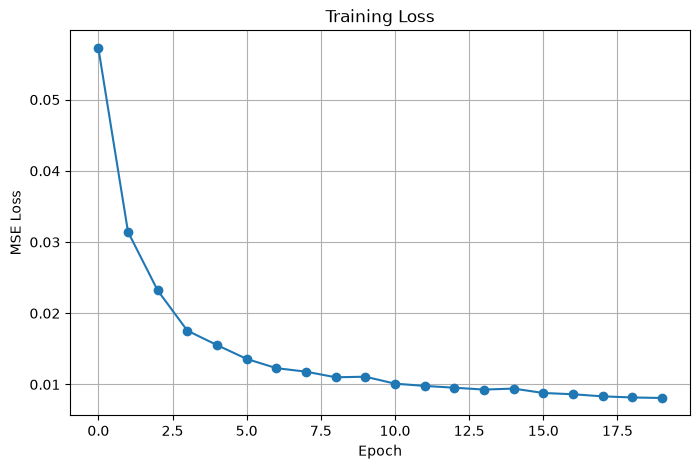

In [427]:
plot_loss(history_full)

In [428]:
model_full.eval()

with torch.inference_mode():

    X_full_device = X_full_tensor.to(device)

    reconstructed_full = model_full(X_full_device)

    full_errors = torch.mean((X_full_device - reconstructed_full) ** 2,dim=1).cpu().numpy()

In [429]:
threshold_full = np.percentile(full_errors,95)


In [430]:
y_pred_full = np.where(full_errors > threshold_full,0,1)

In [431]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix)

y_true_full = y_true.to_numpy()

print(f"Accuracy: {accuracy_score(y_true_full, y_pred_full)}")


print(f"Precision: {precision_score(y_true_full, y_pred_full, pos_label=0, zero_division=0):.4f}")

print(f"Recall: {recall_score(y_true_full, y_pred_full, pos_label=0, zero_division=0):.4f}")

print(f"F1: {f1_score(y_true_full, y_pred_full, pos_label=0, zero_division=0):.4f}")

print(f"Confusion Matrix:\n{confusion_matrix(y_true_full, y_pred_full, labels=[0, 1])}")			


Accuracy: 0.7212
Precision: 0.4400
Recall: 0.0806
F1: 0.1363
Confusion Matrix:
[[ 110 1254]
 [ 140 3496]]


Well, I  tried so many method, I used to use ML IsolationForest, Local Outlier Factor (anomaly detection) from sklearn
Accuracy still 0.7 and Precision and Recall or F1 always low than 50%.
I will demo one

In [432]:
from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(n_estimators=100,contamination=0.10, random_state=42)
isolation_forest.fit(X_full_processed)
y_pred_full_1 = isolation_forest.predict(X_full_processed)
y_pred_full_1 = np.where(y_pred_full_1 == 1, 1, 0) 



In [433]:
y_true_full = y_true.to_numpy()
y_true_full[:5] 

array([1, 1, 1, 0, 1])

In [434]:
accuracy_if = accuracy_score(y_true_full, y_pred_full_1)
precision_if = precision_score(y_true_full, y_pred_full_1, pos_label=0, zero_division=0)
recall_if = recall_score(y_true_full, y_pred_full_1, pos_label=0, zero_division=0)
f1_if = f1_score(y_true_full, y_pred_full_1, pos_label=0, zero_division=0)


In [435]:
print(f"Isolation Forest - Accuracy: {accuracy_if:.4f}")
print(f"Isolation Forest - Precision: {precision_if:.4f}")
print(f"Isolation Forest - Recall: {recall_if:.4f}")
print(f"Isolation Forest - F1: {f1_if:.4f}")

Isolation Forest - Accuracy: 0.6912
Isolation Forest - Precision: 0.3200
Isolation Forest - Recall: 0.1173
Isolation Forest - F1: 0.1717


Oh nothing can supprise me now. I don't believe in this world anymore 😂, I did too much ML method and when I read schedule again, it's require me to do DL. 😇.

Alright, Accuracy still remains at 70%.
As I said before, Precision, Recall, F1_score lower than 50% 

Let do something fun with another neuron network structure

In [436]:
class DenoisingAE(nn.Module):
	def __init__(self, input_dim):
		super().__init__()

		self.encoder = nn.Sequential(
			nn.Linear(input_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64, 32),
			nn.ReLU(),
		)
		self.decoder = nn.Sequential(
			nn.Linear(32,64),
			nn.ReLU(),
			nn.Linear(64,128),
			nn.ReLU(),
			nn.Linear(128, input_dim)	
		)
	def forward(self, x):
		encoded = self.encoder(x)
		decoded = self.decoder(encoded)
		return decoded
	

In [437]:
model_denoising = DenoisingAE(input_dim=input_dim).to(device)

In [438]:
loss_fn_denoising = nn.MSELoss()

optimizer_denoising = torch.optim.Adam(params=model_denoising.parameters(), lr=0.001)

In [439]:
history_denoising = train_step(model_denoising, train_full_dataloader, loss_fn_denoising, optimizer_denoising, EPOCHS, device, noise_factor=0.05)


Epoch [1/20], Loss: 0.0564
Epoch [2/20], Loss: 0.0323
Epoch [3/20], Loss: 0.0235
Epoch [4/20], Loss: 0.0190
Epoch [5/20], Loss: 0.0160
Epoch [6/20], Loss: 0.0147
Epoch [7/20], Loss: 0.0136
Epoch [8/20], Loss: 0.0124
Epoch [9/20], Loss: 0.0117
Epoch [10/20], Loss: 0.0117
Epoch [11/20], Loss: 0.0111
Epoch [12/20], Loss: 0.0113
Epoch [13/20], Loss: 0.0103
Epoch [14/20], Loss: 0.0102
Epoch [15/20], Loss: 0.0099
Epoch [16/20], Loss: 0.0095
Epoch [17/20], Loss: 0.0093
Epoch [18/20], Loss: 0.0096
Epoch [19/20], Loss: 0.0090
Epoch [20/20], Loss: 0.0089


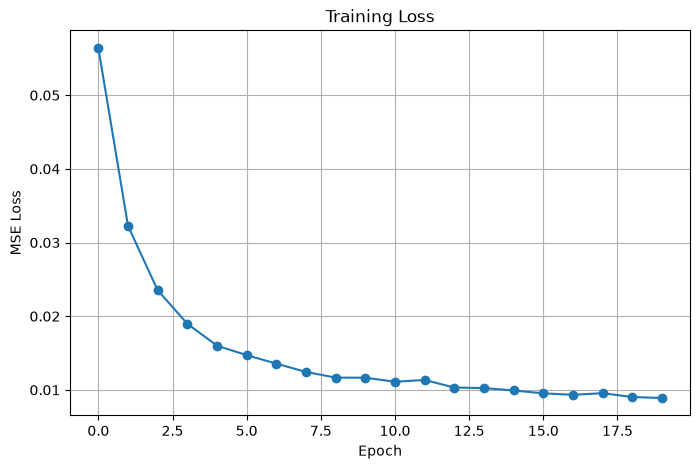

In [440]:
plot_loss(history_denoising)

In [441]:
model_denoising.eval()
with torch.inference_mode():
	X_full_device = X_full_tensor.to(device)
	reconstructed_denoising = model_denoising(X_full_device)
	denoising_errors = torch.mean((X_full_device - reconstructed_denoising) ** 2,dim=1).cpu().numpy()
print(denoising_errors[:10])

[0.01018081 0.00716217 0.54914856 0.00793972 0.00781042 0.0095201
 0.02265804 0.00874165 0.01214074 0.0104165 ]


In [442]:
threshold_denoising = np.percentile(denoising_errors,95)

print("Threshold:", threshold_denoising)

Threshold: 0.01295857


In [443]:
y_pred_denoising = np.where(denoising_errors > threshold_denoising,0,1 )

In [444]:
accuracy = accuracy_score(y_true,y_pred_denoising)

precision = precision_score(y_true,y_pred_denoising,pos_label=0,zero_division=0)

recall = recall_score(y_true,y_pred_denoising,pos_label=0,zero_division=0)

f1 = f1_score(y_true,y_pred_denoising,pos_label=0,zero_division=0)

In [445]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
cm = confusion_matrix(y_true,y_pred_denoising)

print(cm)

Accuracy:  0.7164
Precision: 0.3920
Recall:    0.0718
F1 Score:  0.1214
[[  98 1266]
 [ 152 3484]]


Try with Sparse Autoencoder
https://towardsdatascience.com/building-autoencoders-on-sparse-one-hot-encoded-data-53eefdfdbcc7/

In [ ]:
class SparseAE (nn.Module):
	def __init__(self,input_dim):
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(input_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 64),
			nn.ReLU(),
			nn.Linear(64,32),
			nn.ReLU()
		)

		self.decoder = nn.Sequential(
			nn.Linear(32,64),
			nn.ReLU(),
			nn.Linear(64,128),
			nn.ReLU(),
			nn.Linear(128,input_dim)
		)
	def forward(self, x):
		encoded = self.encoder(x)
		decoded = self.decoder(encoded)

		return decoded, encoded



	

In [447]:
def train_sparse_AE (model: torch.nn.Module, 
					dataloader: torch.utils.data.DataLoader, 
					loss_fn: torch.nn.Module,
					optimizer: torch.optim.Optimizer,
					epochs: int,
					device: None= device,
					sparsity_weight: float= 1e-4):
	model.train()
	history = []

	for epoch in range(epochs):
		epoch_loss = 0.0
		for batch in dataloader:
			X_batch = batch[0].to(device)

			reconstructed, encoded = model(X_batch)
			reconstruction_loss = loss_fn(reconstructed, X_batch)
			sparsity_loss = torch.mean(torch.abs(encoded))
			loss = reconstruction_loss + sparsity_loss*sparsity_weight
			optimizer.zero_grad()

			loss.backward()

			optimizer.step()

			epoch_loss += loss.item()

		avg_epoch_loss = epoch_loss / len(dataloader)

		history.append(avg_epoch_loss)

		print(f"Epoch: {epoch} | Loss: {avg_epoch_loss:.6f}")
	return history



In [448]:
model_sparse = SparseAE(input_dim=input_dim).to(device)

loss_fn_sparse = nn.MSELoss()

optimizer_sparse = torch.optim.Adam(params=model_sparse.parameters(),lr=0.001)

In [449]:
history_sparse = train_sparse_AE(
    model=model_sparse,
    dataloader=train_full_dataloader,
    loss_fn=loss_fn_sparse,
    optimizer=optimizer_sparse,
    epochs=EPOCHS,
    device=device,
    sparsity_weight=1e-4
)

Epoch: 0 | Loss: 0.055667
Epoch: 1 | Loss: 0.032351
Epoch: 2 | Loss: 0.024575
Epoch: 3 | Loss: 0.019837
Epoch: 4 | Loss: 0.015621
Epoch: 5 | Loss: 0.013915
Epoch: 6 | Loss: 0.012802
Epoch: 7 | Loss: 0.012583
Epoch: 8 | Loss: 0.011414
Epoch: 9 | Loss: 0.011135
Epoch: 10 | Loss: 0.010593
Epoch: 11 | Loss: 0.010410
Epoch: 12 | Loss: 0.010198
Epoch: 13 | Loss: 0.010001
Epoch: 14 | Loss: 0.009740
Epoch: 15 | Loss: 0.010190
Epoch: 16 | Loss: 0.009171
Epoch: 17 | Loss: 0.008956
Epoch: 18 | Loss: 0.008884
Epoch: 19 | Loss: 0.008829


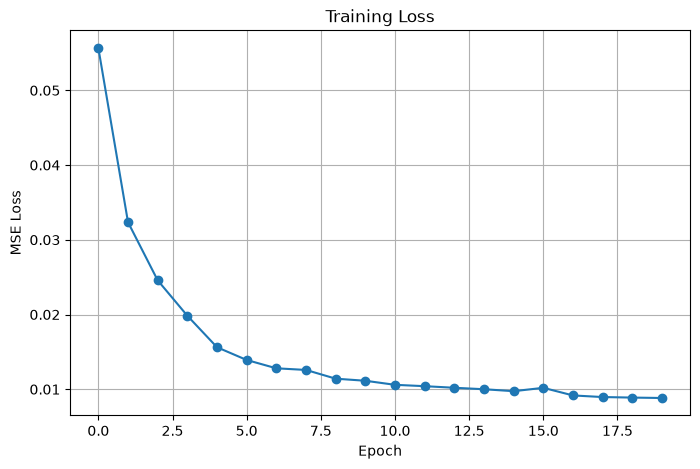

In [450]:
plot_loss(history_sparse)

In [451]:
model_sparse.eval()

with torch.inference_mode():

    X_device = X_full_tensor.to(device)

    reconstructed, _ = model_sparse(X_device)

    sparse_errors = torch.mean((X_device - reconstructed) ** 2,dim=1).cpu().numpy()

In [452]:
threshold_sparse = np.percentile(sparse_errors,95)

y_pred_sparse = np.where(sparse_errors > threshold_sparse,0,1)

In [453]:
accuracy = accuracy_score(
    y_true,
    y_pred_sparse
)

precision = precision_score(
    y_true,
    y_pred_sparse,
    pos_label=0,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred_sparse,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred_sparse,
    pos_label=0,
    zero_division=0
)

In [454]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
cm = confusion_matrix(
    y_true,
    y_pred_denoising
)

print(cm)

Accuracy:  0.7128
Precision: 0.3560
Recall:    0.0652
F1 Score:  0.1103
[[  98 1266]
 [ 152 3484]]
